1- Usando la imagen rosa.png  obtenga el siguiente resultado basicamente es enfocar solamente la rosa roja 

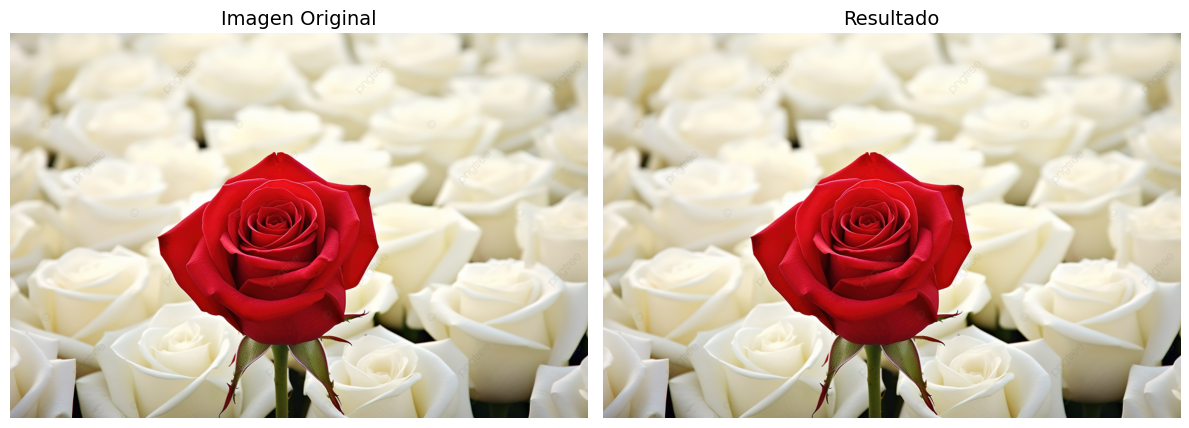

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgbgr = cv2.imread('rosa.png')
img_rgb = cv2.cvtColor(imgbgr, cv2.COLOR_BGR2RGB)

# Segmentar el rojo en HSV
img_hsv = cv2.cvtColor(imgbgr, cv2.COLOR_BGR2HSV)

rb1 = np.array([0,   80,  50], dtype=np.uint8)
ra1 = np.array([10, 255, 255], dtype=np.uint8)
rb2 = np.array([160, 80,  50], dtype=np.uint8)
ra2 = np.array([180, 255, 255], dtype=np.uint8)

m1 = cv2.inRange(img_hsv, rb1, ra1)
m2 = cv2.inRange(img_hsv, rb2, ra2)
mr = cv2.bitwise_or(m1, m2)

# mascara limpia 
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))
mr = cv2.morphologyEx(mr, cv2.MORPH_CLOSE, kernel, iterations=2)
mr = cv2.morphologyEx(mr, cv2.MORPH_OPEN,  kernel, iterations=1)

#extraer rosa
m_3ch = cv2.merge([mr, mr, mr])
rj    = cv2.bitwise_and(imgbgr, m_3ch)        

#extraer fondo sin la rosa
m_inv  = cv2.bitwise_not(mr)
m_inv3 = cv2.merge([m_inv, m_inv, m_inv])
rf     = cv2.bitwise_and(imgbgr, m_inv3)        

# combinamos
resultado_bgr = cv2.add(rj, rf)
resultado_rgb = cv2.cvtColor(resultado_bgr, cv2.COLOR_BGR2RGB) 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Imagen Original', fontsize=14)
axes[0].axis('off')

axes[1].imshow(resultado_rgb)          # usar resultado_rgb, no resultado_bgr
axes[1].set_title('Resultado', fontsize=14)
axes[1].axis('off')

plt.tight_layout()

plt.show()

2- Usando la imagen1.jpg obtiene el siguiente resultado (utiliza mascaras de convolucion) 

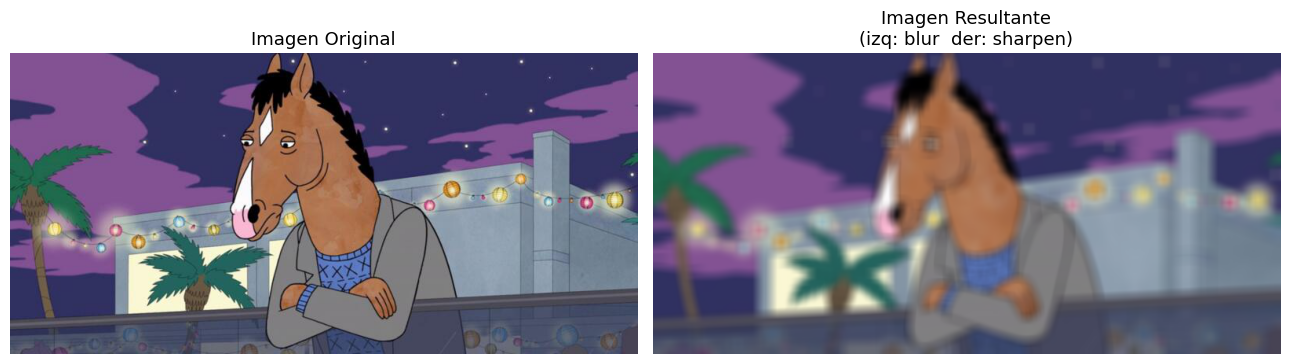

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_bgr.shape[:2]


# Kernel de suavizado 
kernel_blur = np.ones((15, 15), np.float32) / 225
img_blur    = cv2.filter2D(img_bgr, -1, kernel_blur)

# Kernel de enfoque
kernel_sharp = np.array([[ 0, -1,  0],
                          [-1,  5, -1],
                          [ 0, -1,  0]], dtype=np.float32)
img_sharp = cv2.filter2D(img_bgr, -1, kernel_sharp)

# combinamos
mitad       = w // 2*w // 2
resultado   = img_bgr.copy()
resultado[:, :mitad]  = img_blur[:, :mitad] 
resultado[:, mitad:]  = img_sharp[:, mitad:]  

resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Imagen Original', fontsize=13)
axes[0].axis('off')

axes[1].imshow(resultado_rgb)
axes[1].set_title('Imagen Resultante\n(izq: blur  der: sharpen)', fontsize=13)
axes[1].axis('off')


plt.tight_layout()
plt.show()


3- usando la imagen de elementos jpg obtenga el siguiente resultado

Número de elementos encontrados: 49


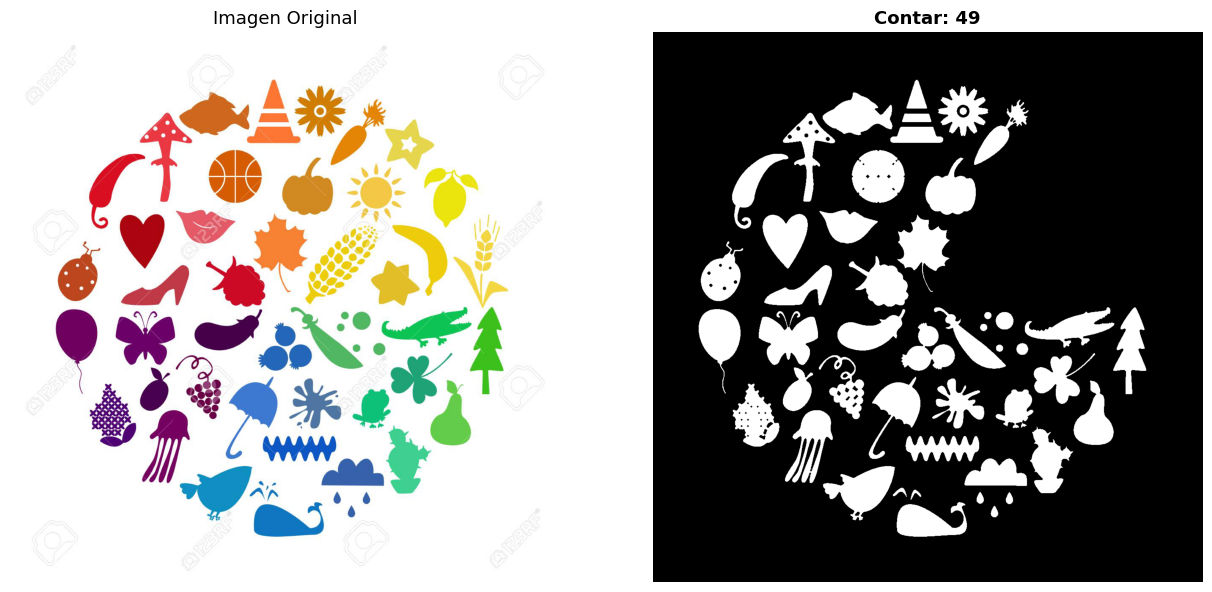

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img_bgr = cv2.imread('Elementos.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

area_min = 100   
elementos = [i for i in range(1, num_labels) if stats[i, cv2.CC_STAT_AREA] >= area_min]
conteo    = len(elementos)
print(f'Número de elementos encontrados: {conteo}')


binaria_resultado = np.zeros_like(gray)
for i in elementos:
    binaria_resultado[labels == i] = 255

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Imagen Original', fontsize=13)
axes[0].axis('off')

axes[1].imshow(binaria_resultado, cmap='gray')
axes[1].set_title(f'Contar: {conteo}', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('resultado_ejercicio3.png', dpi=150, bbox_inches='tight')
plt.show()


4- usando la imagen de colores.jpg cuenta los elementos distinguiendo por colores

RED: 7 objetos
ORANGE: 14 objetos
YELLOW: 6 objetos
GREEN: 11 objetos
BLUE: 6 objetos


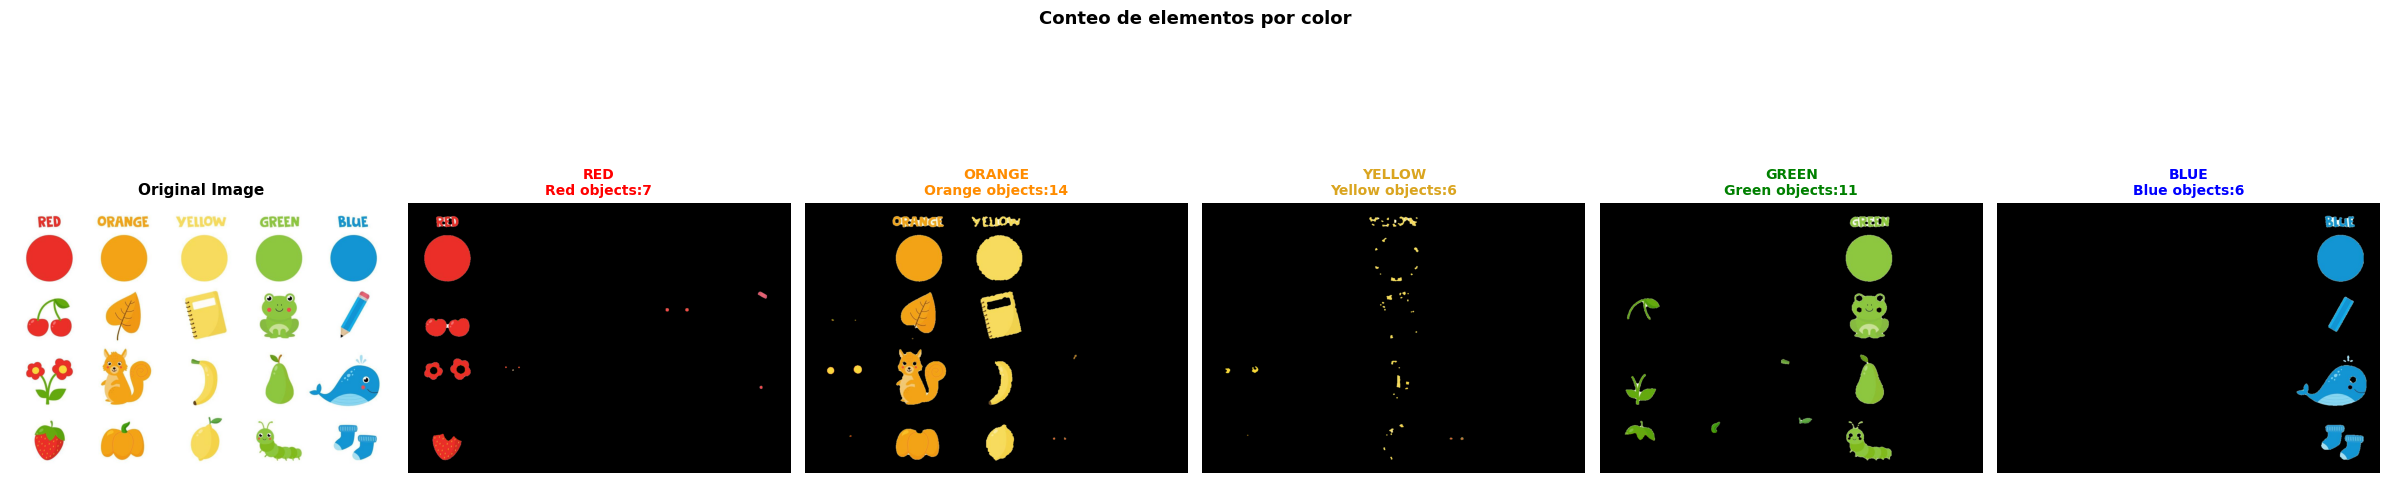

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

colores = {
    'RED':    [(np.array([0,  100, 50]), np.array([10, 255, 255])),
               (np.array([160,100, 50]), np.array([180,255,255]))],
    'ORANGE': [(np.array([11, 100, 50]), np.array([25, 255, 255]))],
    'YELLOW': [(np.array([26, 100, 50]), np.array([34, 255, 255]))],
    'GREEN':  [(np.array([35,  60, 50]), np.array([85, 255, 255]))],
    'BLUE':   [(np.array([86,  60, 50]), np.array([130,255,255]))],
}

img_bgr = cv2.imread('colores.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# mascara limpia y conteo
def mascara_color(hsv, rangos):
    m = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for (lo, hi) in rangos:
        m = cv2.bitwise_or(m, cv2.inRange(hsv, lo, hi))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kernel, iterations=1)
    return m

def contar_contornos(mascara, area_min=200):
    cnts, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return [c for c in cnts if cv2.contourArea(c) > area_min]

#  Procesar cada color
resultados = {}
for nombre, rangos in colores.items():
    masc  = mascara_color(img_hsv, rangos)
    cnts  = contar_contornos(masc)
    # recortamos colores usando la mascara
    region = cv2.bitwise_and(img_rgb, img_rgb, mask=masc)
    resultados[nombre] = {'contornos': cnts, 'region': region, 'count': len(cnts)}
    print(f'{nombre}: {len(cnts)} objetos')

# columnas verticales
n_cols = len(colores) + 1          # original + una por color
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 6))

# mantenemos imagen original a la izquierda
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[0].axis('off')

color_label_colors = {
    'RED': 'red', 'ORANGE': 'darkorange', 'YELLOW': 'goldenrod',
    'GREEN': 'green', 'BLUE': 'blue'
}

for idx, (nombre, datos) in enumerate(resultados.items(), start=1):
    ax = axes[idx]
    ax.imshow(datos['region'])
    ax.set_title(
        f"{nombre}\n{nombre.capitalize()} objects:{datos['count']}",
        fontsize=10,
        color=color_label_colors[nombre],
        fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Conteo de elementos por color', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('resultado_ejercicio4.png', dpi=150, bbox_inches='tight')
plt.show()

5- segun la imagen puntos.png y pato.jpg obtiene el siguiente resultado 

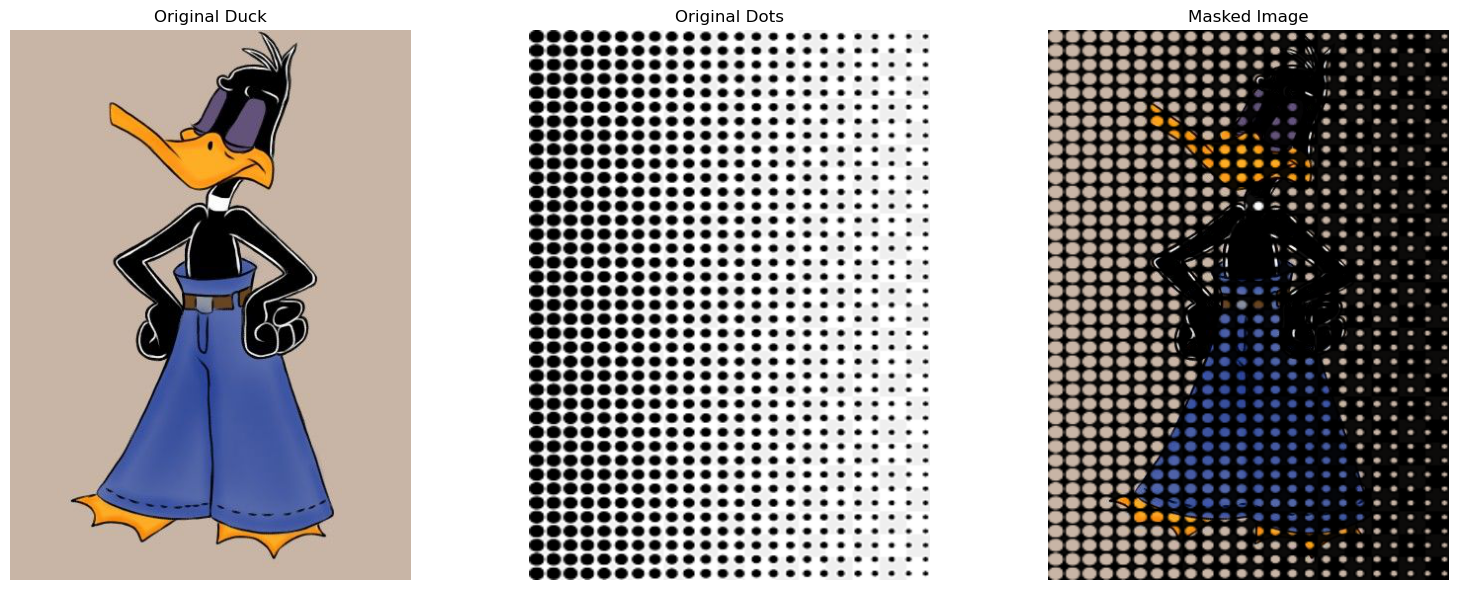

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


pato_bgr   = cv2.imread('pato.jpg')
puntos_bgr = cv2.imread('puntos.png')

pato_rgb   = cv2.cvtColor(pato_bgr,   cv2.COLOR_BGR2RGB)
puntos_rgb = cv2.cvtColor(puntos_bgr, cv2.COLOR_BGR2RGB)


h_p, w_p = pato_bgr.shape[:2]
puntos_res = cv2.resize(puntos_bgr, (w_p, h_p), interpolation=cv2.INTER_LINEAR)


puntos_gray = cv2.cvtColor(puntos_res, cv2.COLOR_BGR2GRAY)


mascara = cv2.bitwise_not(puntos_gray)

# Normalizar máscara a rango [0, 1]
mascara_norm = mascara.astype(np.float32) / 255.0

pato_float = pato_bgr.astype(np.float32)
resultado  = np.zeros_like(pato_float)
for c in range(3): 
    resultado[:, :, c] = pato_float[:, :, c] * mascara_norm

resultado = np.clip(resultado, 0, 255).astype(np.uint8)
resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
puntos_res_rgb = cv2.cvtColor(puntos_res, cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(pato_rgb)
axes[0].set_title('Original Duck', fontsize=12)
axes[0].axis('off')

axes[1].imshow(puntos_res_rgb)
axes[1].set_title('Original Dots', fontsize=12)
axes[1].axis('off')

axes[2].imshow(resultado_rgb)
axes[2].set_title('Masked Image', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()